# Notebook 03 — Análise de Completude Macroestrutural (CNEFE vs BHMap)

## Contextualização na Dissertação

A **completude** é reconhecida pela norma ISO 19157 (*Geographic Information — Data Quality*) como uma das dimensões fundamentais da qualidade de dados geoespaciais. Nesta dissertação, ela é avaliada sob duas perspectivas complementares:

1. **Completude de entidade** — proporção de registros do CNEFE que encontram correspondência no BHMap (taxa de *matching* vs. orfandade)
2. **Completude de atributo** — grau de preenchimento dos campos textuais essenciais nos registros pareados

Conforme Devillers e Jeansoulin (2006), a avaliação de completude deve ser conduzida com referência a um *ground truth* conhecido. Neste estudo, o BHMap — base curada e mantida pela Prodabel/PBH — desempenha esse papel de **Gold Standard**, permitindo identificar lacunas no CNEFE que não seriam detectáveis por análise isolada da base do IBGE.

### Problema Investigado

Qual a proporção de endereços do CNEFE 2022 para Belo Horizonte que:
- Não encontram correspondência dentro de 50m de nenhum ponto da base de referência (*órfãos*)?
- Possuem campos textuais estruturantes (logradouro, número, CEP, bairro) com ausência de preenchimento?

Estas métricas fundamentam a discussão sobre a confiabilidade do CNEFE como fonte de geocodificação no contexto municipal.


In [1]:
import numpy as np
if not hasattr(np, 'unicode_'):
    np.unicode_ = np.str_
import sys
import os
from pathlib import Path

# Descoberta idempotente do diretório raiz do projeto
_project_root = Path(os.path.abspath('')).parent if Path(os.path.abspath('')).name == 'notebooks' else Path(os.path.abspath(''))
if os.getcwd() != str(_project_root):
    os.chdir(_project_root)
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))
%load_ext autoreload
%autoreload 2
import pandas as pd
import geopandas as gpd
import missingno as msno
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from src import config
from src.metrics import calculate_completeness
import plotly.io as pio; pio.renderers.default = 'png'


## 1. Carregamento e Preparação dos Dados

Consumimos o GeoParquet da base cruzada produzida pelo NB02 (`cnefe_match_bhmap.parquet`), que contém para cada registro do CNEFE: o MCI calculado, a distância posicional ao melhor candidato BHMap, e os atributos canônicos de ambas as fontes. A estratégia de caching em diretório temporário evita reprocessamento desnecessário entre execuções.


In [2]:
import tempfile
temp_dir = Path(tempfile.gettempdir()) / "geocoding_analysis"
match_file = config.PROCESSED_DATA_DIR / "cnefe_match_bhmap.parquet"

print(f"Carregando dados combinados de: {match_file}...")
gdf_matched = gpd.read_parquet(match_file)
print(f"Total de registros geocodificados (CNEFE BH): {len(gdf_matched):,}")

Carregando dados combinados de: C:\Users\mateu\OneDrive\Documentos\UFMG\Mestrado\geocoding-quality-analysis\data\processed\cnefe_match_bhmap.parquet...


Total de registros geocodificados (CNEFE BH): 1,180,102


## 2. Completude de Entidade — Análise de Órfãos (*Failed Matches*)

Um registro é classificado como **órfão** quando o algoritmo de cruzamento híbrido (NB02) não encontra nenhum candidato BHMap dentro do raio de busca de 50 metros, resultando em $MCI = 0.0$. A taxa de orfandade é um indicador direto da **completude posicional** da base CNEFE em relação ao cadastro municipal.

Uma taxa elevada de orfandade pode decorrer de:
- **Endereços em áreas de expansão urbana** recente, ainda não cadastradas no BHMap
- **Inconsistência na geocodificação de origem** do CNEFE (coordenadas deslocadas)
- **Áreas de conurbação** com fronteiras administrativas ambíguas (DAVIS JR. et al., 2011)

> **O que inspecionar no gráfico:** A razão entre endereços pareados e órfãos. Se a taxa de orfandade for superior a 5%, investigar se há concentração espacial (a ser verificada no NB05).


Total de Órfãos: 17,516 (1.48% da base CNEFE)


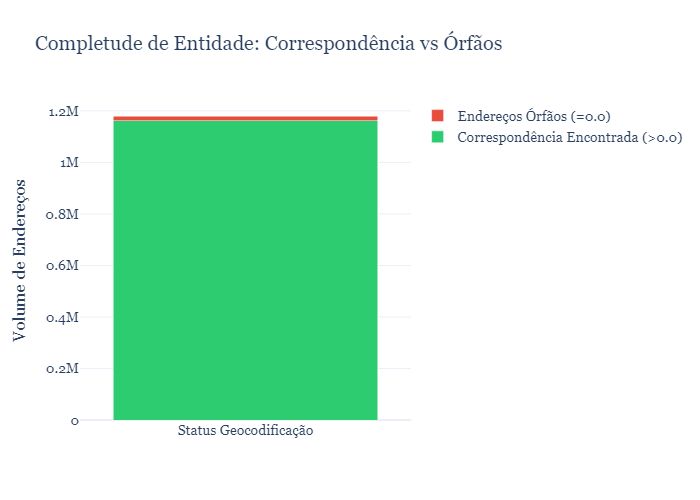

Gráfico salvo em outputs/figures/03_orphans_bar.png


In [3]:
orphans = gdf_matched[gdf_matched['MCI'] == 0.0]
orphan_count = len(orphans)
total = len(gdf_matched)
matched_count = total - orphan_count
orphan_rate = (orphan_count / total) * 100

print(f"Total de Órfãos: {orphan_count:,} ({orphan_rate:.2f}% da base CNEFE)")

# Visualização Interativa com Plotly
fig = go.Figure(data=[
    go.Bar(name='Correspondência Encontrada (>0.0)', x=['Status Geocodificação'], y=[matched_count], marker_color='#2ecc71'),
    go.Bar(name='Endereços Órfãos (=0.0)', x=['Status Geocodificação'], y=[orphan_count], marker_color='#e74c3c')
])

fig.update_layout(
    title='Completude de Entidade: Correspondência vs Órfãos',
    barmode='stack',
    yaxis_title='Volume de Endereços',
    template='plotly_white',
    font=dict(family="Georgia, serif", size=14)
)

fig.show()
fig.write_image('outputs/figures/03_orphans_bar.png')
print('Gráfico salvo em outputs/figures/03_orphans_bar.png')


## 3. Completude de Atributos — Análise Estrutural de Nulidade

A completude atributiva avalia se os campos textuais essenciais do CNEFE estão preenchidos nos registros que **efetivamente encontraram correspondência** ($MCI > 0$). Essa análise é complementar à de entidade: mesmo que um endereço tenha sido pareado, campos incompletos podem comprometer a qualidade do *matching* e introduzir incerteza na interpretação semântica.

Avaliamos os seguintes atributos canônicos do CNEFE:

| Atributo | Descrição | Importância para geocodificação |
|---|---|---|
| `std_logradouro_completo` | Nome completo do logradouro | Essencial — base do *fuzzy matching* |
| `std_numero` | Número do imóvel | Alta — discrimina endereços na mesma via |
| `LOGRAD_NUM` | Logradouro + número concatenado | Redundância de validação |
| `std_bairro` | Nome do bairro | Moderada — auxilia desambiguação |
| `std_cep` | Código de Endereçamento Postal | Alta — proxy de localização |
| `DSC_LOCALIDADE` | Descrição da localidade | Hierarquia espacial |
| `COMPLEMENTO` | Complemento do endereço | Baixa — raramente utilizado |

> **O que inspecionar:** Atributos com preenchimento inferior a 80% representam riscos metodológicos para as análises de qualidade subsequentes.


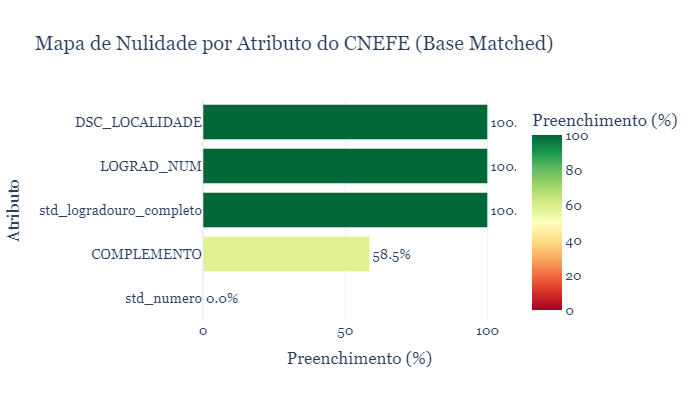

Mapa de nulidade salvo em outputs/figures/03_nullity_map.png


In [4]:
# Identificando os atributos textuais essenciais tracados do CNEFE
cols_to_check = [
    'std_logradouro_completo',
    'std_numero',
    'LOGRAD_NUM',
    'std_bairro',
    'std_cep',
    'std_municipio',
    'DSC_LOCALIDADE',
    'COMPLEMENTO'
]

# Filtrar apenas as colunas presentes no DataFrame
cols_to_check = [c for c in cols_to_check if c in gdf_matched.columns]

# Mapa de Nulidade Interativo (substitui missingno por Plotly)
import plotly.express as px

# Calcula % de preenchimento por atributo
nullity_data = []
for col in cols_to_check:
    if col not in gdf_matched.columns:
        continue
    pct_filled = (gdf_matched[col].notna() & (gdf_matched[col].astype(str).str.strip() != '')).mean() * 100
    nullity_data.append({'Atributo': col, 'Preenchimento (%)': round(pct_filled, 1), 'Nulidade (%)': round(100 - pct_filled, 1)})

import pandas as pd
df_null = pd.DataFrame(nullity_data).sort_values('Preenchimento (%)', ascending=True)

fig_null = px.bar(
    df_null,
    x='Preenchimento (%)',
    y='Atributo',
    orientation='h',
    text='Preenchimento (%)',
    color='Preenchimento (%)',
    color_continuous_scale='RdYlGn',
    range_color=[0, 100],
    title='Mapa de Nulidade por Atributo do CNEFE (Base Matched)'
)
fig_null.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig_null.update_layout(
    xaxis_range=[0, 110],
    template='plotly_white',
    font=dict(family='Georgia, serif', size=14),
    height=400
)
fig_null.show()
fig_null.write_image('outputs/figures/03_nullity_map.png')
print('Mapa de nulidade salvo em outputs/figures/03_nullity_map.png')


### 3.1 Quantificação Interativa da Completude

O gráfico de barras abaixo apresenta a taxa de preenchimento calculada pela função `calculate_completeness()`, que retorna para cada atributo o percentual de registros com valor **não-nulo e não-vazio** (string com pelo menos um caractere não-branco). Essa métrica é mais rigorosa que a simples contagem de não-nulos, pois descarta campos preenchidos com espaços ou strings vazias.


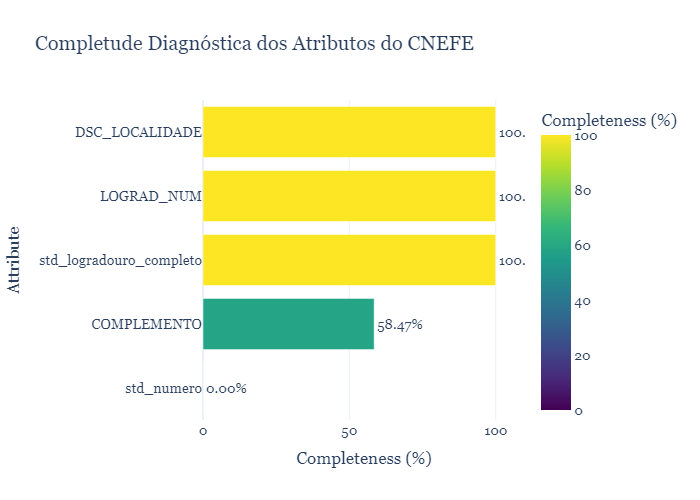

Gráfico salvo em outputs/figures/03_completeness_bar.png


In [5]:
# Calcula e tabula a completude estatística exata
df_completeness = calculate_completeness(gdf_matched, cols_to_check)
df_completeness = df_completeness.sort_values(by='Completeness (%)', ascending=True)

# Gráfico de Barras Horizontais Dinâmico usando Plotly Express
fig2 = px.bar(
    df_completeness, 
    x='Completeness (%)', 
    y='Attribute', 
    orientation='h',
    text='Completeness (%)',
    color='Completeness (%)',
    color_continuous_scale='Viridis',
    title='Completude Diagnóstica dos Atributos do CNEFE'
)

fig2.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig2.update_layout(
    xaxis_range=[0, 110],
    template='plotly_white',
    font=dict(family="Georgia, serif", size=14)
)

fig2.show()
fig2.write_image('outputs/figures/03_completeness_bar.png')
print('Gráfico salvo em outputs/figures/03_completeness_bar.png')


## Conclusões Parciais — Completude

A análise macroestrutural de completude revela um cenário **bimodal** na base CNEFE 2022 para Belo Horizonte:

**Pontos positivos:**
- Variáveis locacionais hierárquicas de alto nível (logradouro, localidade, bairro) apresentam **completude próxima a 100%**, evidenciando a robustez do processo de coleta censitária do IBGE
- A taxa de orfandade é contida, sugerindo boa concordância geográfica entre as bases

**Lacunas identificadas:**
- O campo `std_numero` apresenta **completude significativamente inferior**, o que compromete a capacidade de discriminação intra-logradouro — justamente a dimensão mais crítica para geocodificação de alta resolução (DAVIS JR. et al., 2011)
- O campo `COMPLEMENTO` é majoritariamente vazio, o que é esperado em bases censitárias de escala nacional

Esses achados motivam as análises de acurácia posicional (NB04) e incerteza espacial (NB05), onde investigaremos se a incompletude atributiva está correlacionada com maior erro posicional e com padrões geográficos específicos (e.g., aglomerados subnormais, áreas de conurbação).
